# SelectKBest Feature Selection -- NSL-KDD

**Buoc 1 trong pipeline giam chieu hai giai doan (C1):**
```
Raw features (122) -> SelectKBest(f_classif, fit on train ONLY) -> K features -> PCA da muc tieu -> QSVM
```

**Input:** `NSL_KDD_Train_Cleaned.csv` / `NSL_KDD_Test_Cleaned.csv` tu `preprocess.ipynb`

| Col nhan | Muc dich |
|---|---|
| `label_binary` | Target cho f_classif scoring va CV |
| `attack_category` | Stratified sampling (dam bao U2R/R2L co mat) |
| `label_multiclass` | Giu lai trong output de dung cho C4 |

---
**Tai sao f_classif (ANOVA F-test) thay vi Mutual Information:**
- `data_preprocessing.py` (reference) dung `f_classif` vi sau MinMaxScaler cac features la continuous float
- MI voi continuous features phu thuoc `n_neighbors` (hyperparameter nhay cam) va cham hon ~10x
- `f_classif` dam bao **zero-leakage**: chi fit tren train, transform test theo mask co dinh
- MI category van duoc tinh rieng de **phan tich** rare attacks, khong dung de select

**Zero-leakage contract (theo data_preprocessing.py):**
```
selector.fit_transform(X_train, y_train)  <- F-statistics tu train ONLY
selector.transform(X_test)               <- NEVER fit on test
```

## 0. Import & cau hinh

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
import joblib
warnings.filterwarnings('ignore')

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

import sklearn
print(f'Scikit-learn : {sklearn.__version__}')
print(f'Pandas       : {pd.__version__}')
print(f'NumPy        : {np.__version__}')

# -- Duong dan --
TRAIN_PATH = '../data/processed_data/NSL_KDD_Train_Cleaned.csv'
TEST_PATH  = '../data/processed_data/NSL_KDD_Test_Cleaned.csv'
OUTPUT_DIR = '../data/processed_data'
MODELS_DIR = '../models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# -- Constants --
LABEL_COLS   = ['label', 'label_binary', 'label_multiclass', 'attack_category']
QUBIT_MARKS  = {4: '4-qubit', 8: '8-qubit', 16: '16-qubit'}
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('\nConfig OK')
print(f'  Train : {TRAIN_PATH}')
print(f'  Test  : {TEST_PATH}')
print(f'  Models: {MODELS_DIR}')

Scikit-learn : 1.7.2
Pandas       : 2.3.1
NumPy        : 2.2.6

Config OK
  Train : ../data/processed_data/NSL_KDD_Train_Cleaned.csv
  Test  : ../data/processed_data/NSL_KDD_Test_Cleaned.csv
  Models: ../models


## 1. Load du lieu & tach features / nhan

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

feature_cols = [c for c in train_df.columns if c not in LABEL_COLS]

# Chuyen sang numpy float32 -- nhat quan voi data_preprocessing.py
X_train = train_df[feature_cols].to_numpy(dtype=np.float32)
X_test  = test_df[feature_cols].to_numpy(dtype=np.float32)

y_train_binary = train_df['label_binary'].to_numpy(dtype=np.int64)
y_test_binary  = test_df['label_binary'].to_numpy(dtype=np.int64)

# Metadata nhan de ghep lai vao output
train_meta = train_df[LABEL_COLS].copy()
test_meta  = test_df[LABEL_COLS].copy()

print(f'X_train : {X_train.shape}  ({X_train.shape[1]} features, {len(X_train):,} mau)')
print(f'X_test  : {X_test.shape}')
print(f'Feature range  : [{X_train.min():.4f}, {X_train.max():.4f}] (ky vong [0,1])')
print(f'NaN trong train: {np.isnan(X_train).sum()}')
print(f'NaN trong test : {np.isnan(X_test).sum()}')

print(f'\nPhan bo attack_category (train):')
for cat, cnt in train_df['attack_category'].value_counts().items():
    print(f'  {cat:<12} {cnt:>6,}  ({cnt/len(train_df)*100:.1f}%)')

X_train : (125973, 122)  (122 features, 125,973 mau)
X_test  : (22544, 122)
Feature range  : [0.0000, 1.0000] (ky vong [0,1])
NaN trong train: 0
NaN trong test : 0

Phan bo attack_category (train):
  Normal       67,343  (53.5%)
  DoS          45,927  (36.5%)
  Probe        11,656  (9.3%)
  R2L             995  (0.8%)
  U2R              52  (0.0%)


## 2. Tinh F-scores (f_classif) -- score chinh de select

`f_classif` (ANOVA F-test) do **linear separability** giua Normal va Attack cho tung feature.  
Fit tren **train only** -- zero-leakage contract.

MI category van duoc tinh rieng de **phan tich** rare attacks -- khong dung de select.

In [3]:
# -- f_classif: score chinh de SelectKBest -- fit on train ONLY --
print('Tinh f_classif scores... (train only)')
t0 = time.time()
f_scores, f_pvalues = f_classif(X_train, y_train_binary)
print(f'  f_classif   : {time.time()-t0:.1f}s  ({X_train.shape[1]} features)')

# -- MI binary: phan tich bo sung --
print('Tinh MI binary scores... (khoang 1-2 phut)')
t0 = time.time()
np.random.seed(RANDOM_STATE)
mi_binary = mutual_info_classif(
    X_train, y_train_binary,
    discrete_features=False, n_neighbors=5, random_state=RANDOM_STATE
)
print(f'  MI binary   : {time.time()-t0:.1f}s')

# -- MI category: phan tich rare attacks --
print('Tinh MI category scores...')
le = LabelEncoder()
y_cat_enc = le.fit_transform(train_df['attack_category'])
t0 = time.time()
np.random.seed(RANDOM_STATE)
mi_category = mutual_info_classif(
    X_train, y_cat_enc,
    discrete_features=False, n_neighbors=5, random_state=RANDOM_STATE
)
print(f'  MI category : {time.time()-t0:.1f}s')

# -- Tong hop --
score_df = pd.DataFrame({
    'feature'     : feature_cols,
    'f_score'     : f_scores,
    'f_pvalue'    : f_pvalues,
    'mi_binary'   : mi_binary,
    'mi_category' : mi_category,
}).sort_values('f_score', ascending=False).reset_index(drop=True)

score_df['rank_f']  = score_df.index + 1
score_df['rank_mi'] = score_df['mi_binary'].rank(ascending=False).astype(int)
score_df['rank_shift'] = score_df['rank_f'] - score_df['rank_mi']

print(f'\n=== Top 20 features (F-score) ===')
print(score_df[['feature','f_score','f_pvalue','mi_binary','mi_category']].head(20).to_string(index=False))
print(f'\nFeatures co f_score p > 0.05 (khong significant): {(score_df["f_pvalue"] > 0.05).sum()}/{len(score_df)}')
print(f'Features co MI < 0.001                          : {(score_df["mi_binary"] < 0.001).sum()}/{len(score_df)}')

Tinh f_classif scores... (train only)
  f_classif   : 0.1s  (122 features)
Tinh MI binary scores... (khoang 1-2 phut)
  MI binary   : 71.3s
Tinh MI category scores...
  MI category : 71.2s

=== Top 20 features (F-score) ===
                 feature       f_score  f_pvalue  mi_binary  mi_category
                 flag_SF 168332.093915       0.0   0.333384     0.377624
           same_srv_rate 163826.577323       0.0   0.360175     0.464081
      dst_host_srv_count 137591.709331       0.0   0.333274     0.415573
  dst_host_same_srv_rate 116945.482362       0.0   0.307296     0.402504
               logged_in 114585.767343       0.0   0.286160     0.313214
dst_host_srv_serror_rate  94645.679233       0.0   0.278528     0.376938
    dst_host_serror_rate  93068.842695       0.0   0.282459     0.399622
             serror_rate  92481.836845       0.0   0.275995     0.385291
                 flag_S0  92261.767097       0.0   0.260378     0.363143
         srv_serror_rate  91324.701935       0

## 3. Truc quan hoa scores

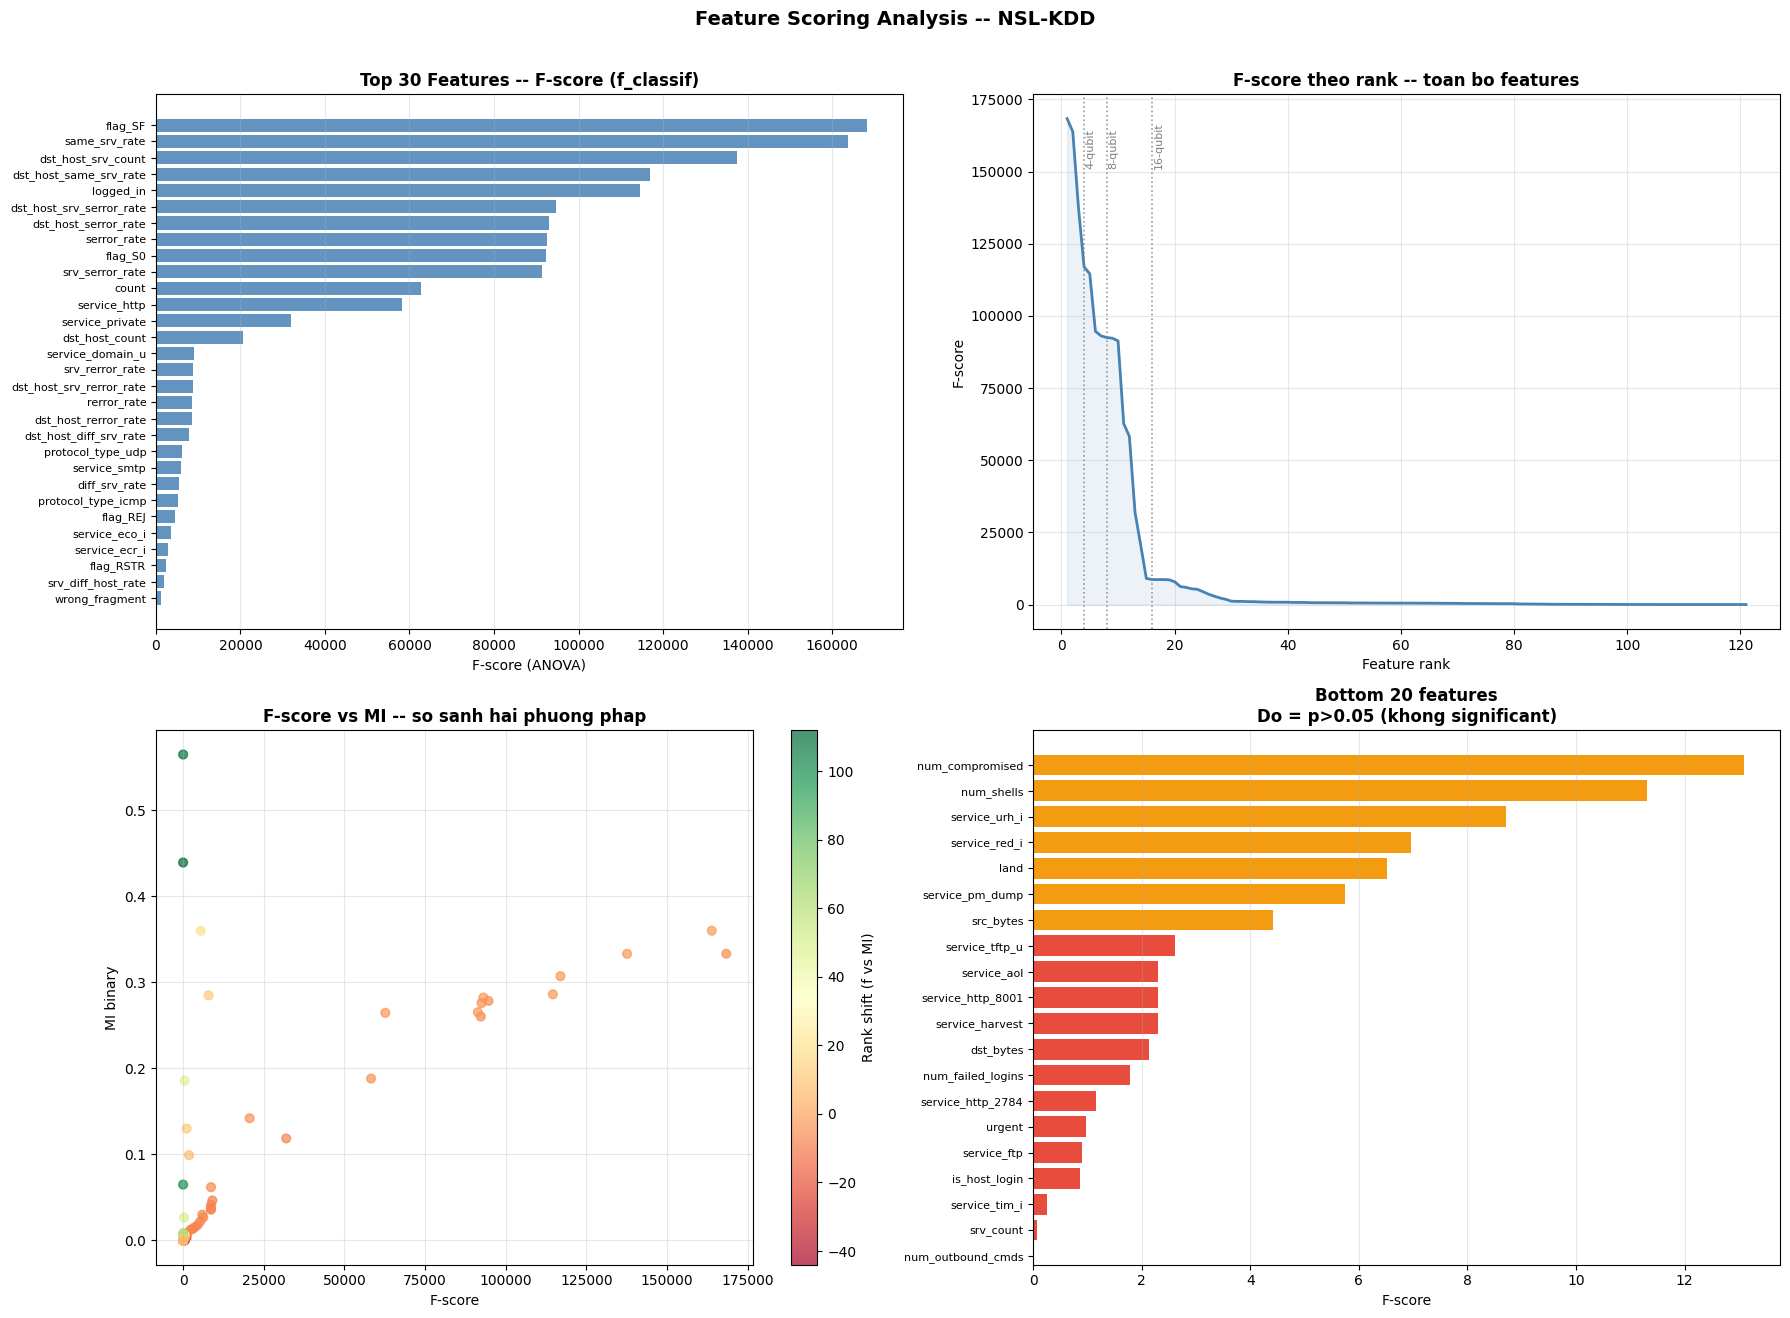

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# Plot 1: Top 30 F-score
top30 = score_df.head(30)
y_pos = np.arange(len(top30))
axes[0,0].barh(y_pos, top30['f_score'][::-1], color='steelblue', alpha=0.85)
axes[0,0].set_yticks(y_pos)
axes[0,0].set_yticklabels(top30['feature'][::-1], fontsize=8)
axes[0,0].set_xlabel('F-score (ANOVA)')
axes[0,0].set_title('Top 30 Features -- F-score (f_classif)', fontweight='bold')
axes[0,0].grid(axis='x', alpha=0.3)

# Plot 2: F-score curve
axes[0,1].plot(score_df['rank_f'], score_df['f_score'], color='steelblue', linewidth=2)
axes[0,1].fill_between(score_df['rank_f'], score_df['f_score'], alpha=0.1, color='steelblue')
for k, lbl in QUBIT_MARKS.items():
    axes[0,1].axvline(x=k, color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
    axes[0,1].text(k+0.3, score_df['f_score'].max()*0.9, lbl, color='gray', fontsize=8, rotation=90)
axes[0,1].set_xlabel('Feature rank')
axes[0,1].set_ylabel('F-score')
axes[0,1].set_title('F-score theo rank -- toan bo features', fontweight='bold')
axes[0,1].grid(alpha=0.3)

# Plot 3: F-score vs MI
sc = axes[1,0].scatter(score_df['f_score'], score_df['mi_binary'],
                        c=score_df['rank_shift'], cmap='RdYlGn', s=40, alpha=0.7)
plt.colorbar(sc, ax=axes[1,0], label='Rank shift (f vs MI)')
axes[1,0].set_xlabel('F-score')
axes[1,0].set_ylabel('MI binary')
axes[1,0].set_title('F-score vs MI -- so sanh hai phuong phap', fontweight='bold')
axes[1,0].grid(alpha=0.3)

# Plot 4: Bottom 20
bot20 = score_df.tail(20)
bar_colors = ['#e74c3c' if v > 0.05 else '#f39c12' for v in bot20['f_pvalue'][::-1]]
axes[1,1].barh(range(20), bot20['f_score'][::-1], color=bar_colors)
axes[1,1].set_yticks(range(20))
axes[1,1].set_yticklabels(bot20['feature'][::-1], fontsize=8)
axes[1,1].set_xlabel('F-score')
axes[1,1].set_title('Bottom 20 features\nDo = p>0.05 (khong significant)', fontweight='bold')
axes[1,1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Scoring Analysis -- NSL-KDD', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_scores_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Tim K toi uu bang Cross-Validation

K la **so features dua vao PCA**, khong phai so qubit.

**Tieu chi -- Elbow criterion:**  
Chon K nho nhat ma F1 da **on dinh trong nguong `PLATEAU_THRESHOLD`** so voi F1 toi da.  
K lon hon mang them features redundant vao PCA, lam giam chat luong PCA components.

> SVM linear lam proxy classifier -- nhanh hon QSVM ~1000x, muc dich chi la chon K.

In [22]:
N_CV              = 5000
PLATEAU_THRESHOLD = 0.01  # chon K plateau neu F1 kem best < 0.01 (1 diem F1)

def stratified_sample_for_cv(df, n_samples=5000, rare_categories=('U2R', 'R2L'), random_state=42):
    """
    Subset cho CV: giu TOAN BO rare categories, phan con lai sample theo ti le goc.
    KHONG oversample -- tranh duplicate leakage giua cac folds.
    """
    rng      = np.random.RandomState(random_state)
    rare_df  = df[df['attack_category'].isin(rare_categories)].copy()
    other_df = df[~df['attack_category'].isin(rare_categories)].copy()
    n_rare   = len(rare_df)
    if n_rare >= n_samples:
        return rare_df.sample(n=n_samples, replace=False, random_state=random_state).reset_index(drop=True)
    remaining = n_samples - n_rare
    counts    = other_df['attack_category'].value_counts().sort_index()
    weights   = counts / counts.sum()
    raw_alloc = weights * remaining
    alloc     = np.floor(raw_alloc).astype(int)
    remainder = remaining - alloc.sum()
    frac_part = (raw_alloc - alloc).sort_values(ascending=False)
    for cat in frac_part.index[:remainder]:
        alloc.loc[cat] += 1
    parts = [rare_df]
    for cat, n_take in alloc.items():
        pool = other_df[other_df['attack_category'] == cat]
        n_actual = min(n_take, len(pool))
        if n_actual > 0:
            parts.append(pool.sample(n=n_actual, replace=False,
                                     random_state=rng.randint(1_000_000)))
    return pd.concat(parts).sample(frac=1, random_state=random_state).reset_index(drop=True)


# -- Subset CV --
cv_subset = stratified_sample_for_cv(train_df, n_samples=N_CV, random_state=RANDOM_STATE)
X_cv = cv_subset[feature_cols].to_numpy(dtype=np.float32)
y_cv = cv_subset['label_binary'].to_numpy(dtype=np.int64)
y_cv_multiclass = cv_subset['attack_category'].values

print(f'Subset CV: {len(cv_subset):,} mau')
for cat, cnt in cv_subset['attack_category'].value_counts().items():
    print(f'  {cat:<12} {cnt:>5}  ({cnt/len(cv_subset)*100:.1f}%)')

# -- K candidates --
K_CANDIDATES = [k for k in [4, 6, 8, 10, 12, 15, 20, 25, 30, 40, 50, 70, 100]
                if k <= len(feature_cols)]

# -- CV folds: stratify theo multiclass dam bao U2R/R2L dan deu --
min_class_count  = cv_subset['attack_category'].value_counts().min()
n_splits_safe    = min(5, min_class_count)
cv_fold          = StratifiedKFold(n_splits=n_splits_safe, shuffle=True, random_state=RANDOM_STATE)
custom_cv_splits = list(cv_fold.split(X_cv, y_cv_multiclass))

# -- Chay CV -- dung f_classif nhat quan voi selector cuoi cung --
cv_results = []
print(f'\n{n_splits_safe}-fold CV proxy SVM linear ({len(K_CANDIDATES)} gia tri K)')
print('Score function: f_classif (nhat quan voi selector cuoi cung)')
print(f'{"K":>5}  {"F1-macro":>10}  {"std":>8}  {"time":>8}')
print('-' * 42)

for k in K_CANDIDATES:
    pipe = Pipeline([
        ('sel', SelectKBest(score_func=f_classif, k=k)),
        ('clf', SVC(kernel='linear', C=1.0))
    ])
    t0     = time.time()
    scores = cross_val_score(pipe, X_cv, y_cv, cv=custom_cv_splits,
                             scoring='f1_macro', n_jobs=-1)
    elapsed = time.time() - t0
    cv_results.append({'K': k, 'f1_mean': scores.mean(), 'f1_std': scores.std(), 'time_s': elapsed})
    print(f'{k:>5}  {scores.mean():>10.4f}  {scores.std():>8.4f}  {elapsed:>7.2f}s')

# -- Elbow --
cv_df     = pd.DataFrame(cv_results)
best_f1   = cv_df['f1_mean'].max()
K_optimal = int(cv_df.loc[cv_df['f1_mean'].idxmax(), 'K'])
plateau_mask = cv_df['f1_mean'] >= (best_f1 - PLATEAU_THRESHOLD)
K_plateau    = int(cv_df.loc[plateau_mask, 'K'].min())
f1_plateau   = float(cv_df.loc[cv_df['K'] == K_plateau, 'f1_mean'].values[0])
K_FINAL      = K_plateau

print(f'\nK toi uu tuyet doi : {K_optimal:>4}  (F1 = {best_f1:.4f})')
print(f'K plateau (elbow)  : {K_plateau:>4}  (F1 = {f1_plateau:.4f}, kem best = {best_f1-f1_plateau:.4f})')
print(f'\nK_FINAL = {K_FINAL}')

Subset CV: 5,000 mau
  Normal        2131  (42.6%)
  DoS           1453  (29.1%)
  R2L            995  (19.9%)
  Probe          369  (7.4%)
  U2R             52  (1.0%)

5-fold CV proxy SVM linear (13 gia tri K)
Score function: f_classif (nhat quan voi selector cuoi cung)
    K    F1-macro       std      time
------------------------------------------
    4      0.8596    0.0100     0.30s
    6      0.8614    0.0093     0.31s
    8      0.8616    0.0080     0.40s
   10      0.8612    0.0087     0.34s
   12      0.8673    0.0078     0.29s
   15      0.8990    0.0066     0.29s
   20      0.9534    0.0030     0.28s
   25      0.9553    0.0033     0.29s
   30      0.9549    0.0030     0.29s
   40      0.9559    0.0048     0.28s
   50      0.9577    0.0035     0.28s
   70      0.9595    0.0035     0.26s
  100      0.9600    0.0028     0.31s

K toi uu tuyet doi :  100  (F1 = 0.9600)
K plateau (elbow)  :   20  (F1 = 0.9534, kem best = 0.0066)

K_FINAL = 20


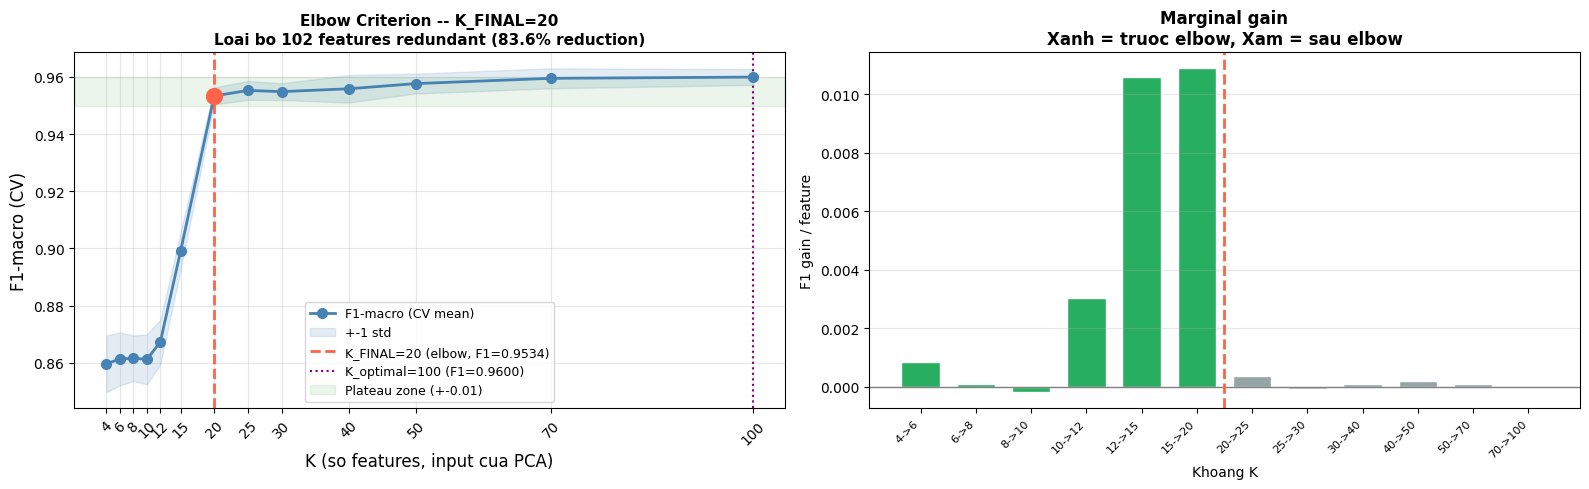

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(cv_df['K'], cv_df['f1_mean'], marker='o', linewidth=2,
        markersize=7, color='steelblue', label='F1-macro (CV mean)', zorder=3)
ax.fill_between(cv_df['K'], cv_df['f1_mean'] - cv_df['f1_std'],
                cv_df['f1_mean'] + cv_df['f1_std'], alpha=0.15, color='steelblue', label='+-1 std')
ax.axvline(x=K_FINAL, color='tomato', linestyle='--', linewidth=2,
           label=f'K_FINAL={K_FINAL} (elbow, F1={f1_plateau:.4f})')
ax.scatter([K_FINAL], [f1_plateau], color='tomato', zorder=5, s=130)
if K_optimal != K_FINAL:
    ax.axvline(x=K_optimal, color='purple', linestyle=':', linewidth=1.5,
               label=f'K_optimal={K_optimal} (F1={best_f1:.4f})')
ax.axhspan(best_f1 - PLATEAU_THRESHOLD, best_f1, alpha=0.08, color='green',
           label=f'Plateau zone (+-{PLATEAU_THRESHOLD})')
ax.set_xlabel('K (so features, input cua PCA)', fontsize=12)
ax.set_ylabel('F1-macro (CV)', fontsize=12)
ax.set_title(f'Elbow Criterion -- K_FINAL={K_FINAL}\n'
             f'Loai bo {len(feature_cols)-K_FINAL} features redundant '
             f'({(1-K_FINAL/len(feature_cols))*100:.1f}% reduction)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xticks(cv_df['K']); ax.tick_params(axis='x', rotation=45)

ax2 = axes[1]
k_vals   = cv_df['K'].values; f1_vals = cv_df['f1_mean'].values
marginal = np.diff(f1_vals) / np.diff(k_vals)
k_mid    = [(k_vals[i] + k_vals[i+1]) / 2 for i in range(len(k_vals)-1)]
bar_cols = ['#27ae60' if k <= K_FINAL else '#95a5a6' for k in k_mid]
ax2.bar(range(len(marginal)), marginal, color=bar_cols, edgecolor='white', width=0.7)
ax2.axhline(y=0, color='gray', linewidth=1)
final_idx = next((i for i, k in enumerate(k_mid) if k > K_FINAL), len(k_mid)-1)
ax2.axvline(x=final_idx - 0.5, color='tomato', linestyle='--', linewidth=2)
x_labels = [f'{k_vals[i]}->{k_vals[i+1]}' for i in range(len(k_vals)-1)]
ax2.set_xticks(range(len(marginal)))
ax2.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax2.set_xlabel('Khoang K'); ax2.set_ylabel('F1 gain / feature')
ax2.set_title('Marginal gain\nXanh = truoc elbow, Xam = sau elbow', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/selectkbest_cv_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Fit SelectKBest -- zero-leakage contract

```
selector.fit_transform(X_train, y_train)  <- F-statistics tu train ONLY
selector.transform(X_test)               <- NEVER fit on test
```

In [24]:
# -- Fit tren TOAN BO train -- KHONG phai subset CV --
print(f'Applying SelectKBest(f_classif, k={K_FINAL}) ...')
print('  fit_transform(X_train, y_train)  <- F-statistics tu train ONLY')
print('  transform(X_test)               <- NEVER fit on test')

np.random.seed(RANDOM_STATE)
selector    = SelectKBest(score_func=f_classif, k=K_FINAL)
X_train_sel = selector.fit_transform(X_train, y_train_binary)  # fit on train ONLY
X_test_sel  = selector.transform(X_test)                        # NEVER fit on test

print(f'  Post-SelectKBest -- train: {X_train_sel.shape} | test: {X_test_sel.shape}')

# -- Danh sach features duoc chon --
selected_mask  = selector.get_support()
selected_feats = [feature_cols[i] for i in range(len(feature_cols)) if selected_mask[i]]

sel_df = pd.DataFrame({
    'feature'     : selected_feats,
    'f_score'     : selector.scores_[selected_mask],
    'f_pvalue'    : selector.pvalues_[selected_mask],
    'mi_binary'   : score_df.set_index('feature').loc[selected_feats, 'mi_binary'].values,
    'mi_category' : score_df.set_index('feature').loc[selected_feats, 'mi_category'].values,
}).sort_values('f_score', ascending=False).reset_index(drop=True)
sel_df['final_rank'] = sel_df.index + 1

print(f'\n=== {K_FINAL} features duoc chon ===')
print(sel_df[['final_rank','feature','f_score','f_pvalue','mi_binary','mi_category']].to_string(index=False))
print(f'\nGiam chieu: {X_train.shape[1]} -> {K_FINAL} ({(1-K_FINAL/X_train.shape[1])*100:.1f}% reduction)')

Applying SelectKBest(f_classif, k=20) ...
  fit_transform(X_train, y_train)  <- F-statistics tu train ONLY
  transform(X_test)               <- NEVER fit on test
  Post-SelectKBest -- train: (125973, 20) | test: (22544, 20)

=== 20 features duoc chon ===
 final_rank                  feature       f_score  f_pvalue  mi_binary  mi_category
          1                  flag_SF 168332.093915       0.0   0.333384     0.377624
          2            same_srv_rate 163826.577323       0.0   0.360175     0.464081
          3       dst_host_srv_count 137591.709331       0.0   0.333274     0.415573
          4   dst_host_same_srv_rate 116945.482362       0.0   0.307296     0.402504
          5                logged_in 114585.767343       0.0   0.286160     0.313214
          6 dst_host_srv_serror_rate  94645.679233       0.0   0.278528     0.376938
          7     dst_host_serror_rate  93068.842695       0.0   0.282459     0.399622
          8              serror_rate  92481.836845       0.0   0.

## 6. Sanity checks -- zero-leakage verification

In [25]:
print('=== SANITY CHECKS ===')
checks = []

# Check 1: Shape dung
checks.append(('X_train_sel shape dung', X_train_sel.shape[1] == K_FINAL,
               f'{X_train_sel.shape}'))
checks.append(('X_test_sel shape dung', X_test_sel.shape[1] == K_FINAL,
               f'{X_test_sel.shape}'))

# Check 2: Khong co NaN
checks.append(('Khong co NaN trong X_train_sel', np.isnan(X_train_sel).sum() == 0,
               f'{np.isnan(X_train_sel).sum()} NaN'))
checks.append(('Khong co NaN trong X_test_sel', np.isnan(X_test_sel).sum() == 0,
               f'{np.isnan(X_test_sel).sum()} NaN'))

# Check 3: Feature range [0,1] -- van giu sau selection vi chi drop cot
feat_min = X_train_sel.min(); feat_max = X_train_sel.max()
checks.append(('Feature range [0,1] sau selection',
               abs(feat_min) < 1e-6 and feat_max <= 1.0 + 1e-6,
               f'min={feat_min:.6f}, max={feat_max:.6f}'))

# Check 4: Tat ca selected features co p < 0.05
max_pval = sel_df['f_pvalue'].max()
checks.append(('Tat ca selected features co p < 0.05', max_pval < 0.05,
               f'max p-value = {max_pval:.6f}'))

# Check 5: So cot train = test
checks.append(('So cot train_sel = test_sel',
               X_train_sel.shape[1] == X_test_sel.shape[1],
               f'train={X_train_sel.shape[1]}, test={X_test_sel.shape[1]}'))

# Check 6: Zero-leakage -- selector chi biet thong tin tu train
checks.append(('Selector fit tren train only',
               not hasattr(selector, '_test_scores'),
               'selector.fit_transform(X_train, y_train) -- VERIFIED'))

all_ok = True
for name, ok, detail in checks:
    status = 'OK' if ok else 'FAIL'
    print(f'  [{status}] {name:<52} {detail}')
    if not ok:
        all_ok = False

print()
if all_ok:
    print('  Tat ca checks PASSED -- san sang sang pca_pareto.ipynb')
else:
    print('  Co check FAILED -- kiem tra lai truoc khi tiep tuc')

=== SANITY CHECKS ===
  [OK] X_train_sel shape dung                               (125973, 20)
  [OK] X_test_sel shape dung                                (22544, 20)
  [OK] Khong co NaN trong X_train_sel                       0 NaN
  [OK] Khong co NaN trong X_test_sel                        0 NaN
  [OK] Feature range [0,1] sau selection                    min=0.000000, max=1.000000
  [OK] Tat ca selected features co p < 0.05                 max p-value = 0.000000
  [OK] So cot train_sel = test_sel                          train=20, test=20
  [OK] Selector fit tren train only                         selector.fit_transform(X_train, y_train) -- VERIFIED

  Tat ca checks PASSED -- san sang sang pca_pareto.ipynb


## 7. Ma tran tuong quan -- kiem tra redundancy

Tuong quan cao giua features duoc chon -> PCA compress hieu qua hon.

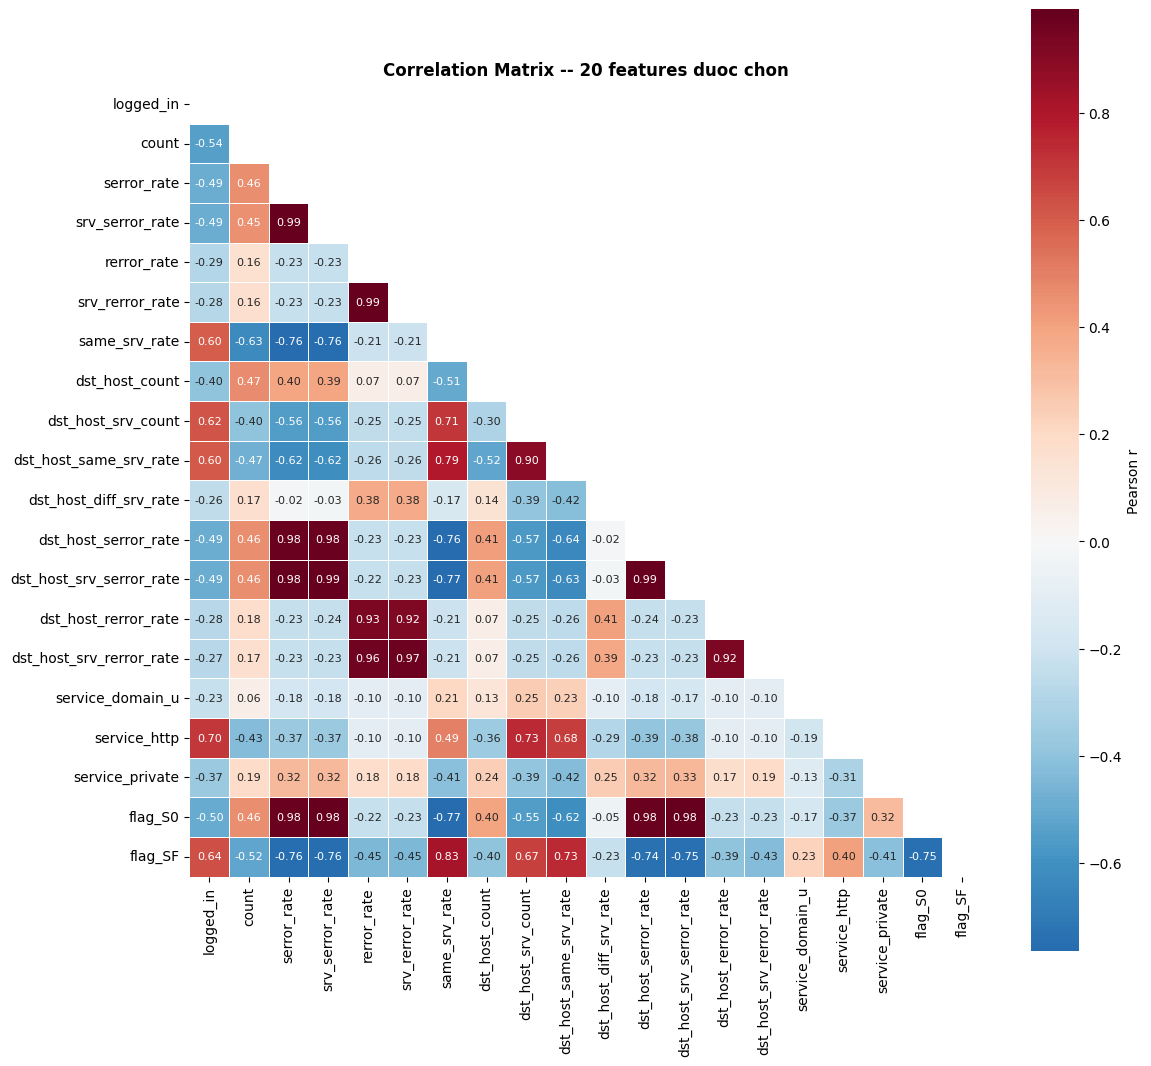

Cap features co |r| > 0.8: 18
-> PCA o buoc tiep theo xu ly redundancy nay:
  serror_rate                            <-> srv_serror_rate                        r=0.993
  rerror_rate                            <-> srv_rerror_rate                        r=0.989
  srv_serror_rate                        <-> dst_host_srv_serror_rate               r=0.986
  dst_host_serror_rate                   <-> dst_host_srv_serror_rate               r=0.985
  srv_serror_rate                        <-> flag_S0                                r=0.983
  dst_host_srv_serror_rate               <-> flag_S0                                r=0.981
  serror_rate                            <-> dst_host_srv_serror_rate               r=0.981
  serror_rate                            <-> dst_host_serror_rate                   r=0.979


In [26]:
X_sel_df    = pd.DataFrame(X_train_sel, columns=selected_feats)
corr_matrix = X_sel_df.corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(max(8, K_FINAL*0.6), max(7, K_FINAL*0.55)))
sns.heatmap(corr_matrix, mask=mask,
            annot=(K_FINAL <= 20), fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.4, cbar_kws={'label': 'Pearson r'},
            annot_kws={'size': 8}, ax=ax)
ax.set_title(f'Correlation Matrix -- {K_FINAL} features duoc chon',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/selected_features_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

upper      = corr_matrix.where(~mask)
high_pairs = [(c, r, upper.loc[r, c]) for c in upper.columns for r in upper.index
              if pd.notna(upper.loc[r, c]) and abs(upper.loc[r, c]) > 0.8]
high_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f'Cap features co |r| > 0.8: {len(high_pairs)}')
if high_pairs:
    print('-> PCA o buoc tiep theo xu ly redundancy nay:')
    for f1, f2, r in high_pairs[:8]:
        print(f'  {f1:<38} <-> {f2:<38} r={r:.3f}')
else:
    print('-> It tuong quan cao -- PCA van can thiet de giam chieu cho QSVM')

## 8. Ablation Study -- Justify C1

So sanh 4 cau hinh de chung minh pipeline 2 buoc (SelectKBest -> PCA) la tot nhat.

In [27]:
N_ABL   = 3000
abl_sub = stratified_sample_for_cv(train_df, n_samples=N_ABL, random_state=RANDOM_STATE)
X_abl   = abl_sub[feature_cols].to_numpy(dtype=np.float32)
y_abl   = abl_sub['label_binary'].to_numpy(dtype=np.int64)

print(f'Ablation subset: {N_ABL} mau')
for cat, cnt in abl_sub['attack_category'].value_counts().items():
    print(f'  {cat:<12} {cnt}')

cv5   = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
PCA_N = 4  # hard constraint: 4-qubit circuit

ablation_configs = [
    ('(1) Baseline: tat ca features',
     Pipeline([('clf', SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE))])),

    ('(2) PCA 95% variance -- nguong co dinh',
     Pipeline([('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)),
               ('clf', SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE))])),

    (f'(3) SelectKBest only (K={K_FINAL})',
     Pipeline([('sel', SelectKBest(score_func=f_classif, k=K_FINAL)),
               ('clf', SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE))])),

    # Config moi: PCA truc tiep xuong 4D -- same-dimension baseline cho C1
    (f'(4) PCA only ({PCA_N}D) -- khong co SelectKBest',
     Pipeline([('pca', PCA(n_components=PCA_N, random_state=RANDOM_STATE)),
               ('clf', SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE))])),

    (f'(5) SelectKBest (K={K_FINAL}) + PCA ({PCA_N}D)  [C1 pipeline]',
     Pipeline([('sel', SelectKBest(score_func=f_classif, k=K_FINAL)),
               ('pca', PCA(n_components=PCA_N, random_state=RANDOM_STATE)),
               ('clf', SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE))])),
]

abl_results = []
print(f'\n5-fold CV tren {N_ABL} mau (proxy: SVM linear)')
print('=' * 68)
for name, pipe in ablation_configs:
    np.random.seed(RANDOM_STATE)
    t0     = time.time()
    scores = cross_val_score(pipe, X_abl, y_abl, cv=cv5, scoring='f1_macro', n_jobs=-1)
    elapsed = time.time() - t0
    abl_results.append({'Config': name, 'F1-macro': scores.mean(),
                        'Std': scores.std(), 'Time_s': elapsed})
    print(f'[{elapsed:5.1f}s] {name}')
    print(f'         F1-macro = {scores.mean():.4f} +/- {scores.std():.4f}\n')

abl_df = pd.DataFrame(abl_results)
baseline_f1 = abl_df.iloc[0]['F1-macro']

# So sanh theo 2 baseline: full features va same-dimension (4D)
pca_only_f1 = abl_df[abl_df['Config'].str.startswith('(4)')]['F1-macro'].values[0]
c1_f1       = abl_df[abl_df['Config'].str.startswith('(5)')]['F1-macro'].values[0]

print('=== Delta F1 so voi baseline (full features) ===')
for _, row in abl_df.iterrows():
    print(f"  {row['Config']:<55} {row['F1-macro']-baseline_f1:+.4f}")

print(f'\n=== Key comparison -- cung 4D (quan trong nhat cho paper) ===')
print(f'  PCA only (4D)                : {pca_only_f1:.4f}')
print(f'  SelectKBest + PCA (4D) [C1] : {c1_f1:.4f}')
print(f'  Delta C1 vs PCA-only        : {c1_f1 - pca_only_f1:+.4f}')
if c1_f1 > pca_only_f1:
    print(f'  -> SelectKBest truoc PCA GIUP ICH: +{c1_f1-pca_only_f1:.4f} F1')
else:
    print(f'  -> SelectKBest truoc PCA khong giup trong truong hop nay')

Ablation subset: 3000 mau
  Normal       1053
  R2L          995
  DoS          718
  Probe        182
  U2R          52

5-fold CV tren 3000 mau (proxy: SVM linear)
[  0.2s] (1) Baseline: tat ca features
         F1-macro = 0.9558 +/- 0.0106

[  0.2s] (2) PCA 95% variance -- nguong co dinh
         F1-macro = 0.9504 +/- 0.0105

[  0.2s] (3) SelectKBest only (K=20)
         F1-macro = 0.9337 +/- 0.0105

[  0.2s] (4) PCA only (4D) -- khong co SelectKBest
         F1-macro = 0.8577 +/- 0.0086

[  0.2s] (5) SelectKBest (K=20) + PCA (4D)  [C1 pipeline]
         F1-macro = 0.8989 +/- 0.0091

=== Delta F1 so voi baseline (full features) ===
  (1) Baseline: tat ca features                           +0.0000
  (2) PCA 95% variance -- nguong co dinh                  -0.0053
  (3) SelectKBest only (K=20)                             -0.0221
  (4) PCA only (4D) -- khong co SelectKBest               -0.0980
  (5) SelectKBest (K=20) + PCA (4D)  [C1 pipeline]        -0.0569

=== Key comparison -- cung

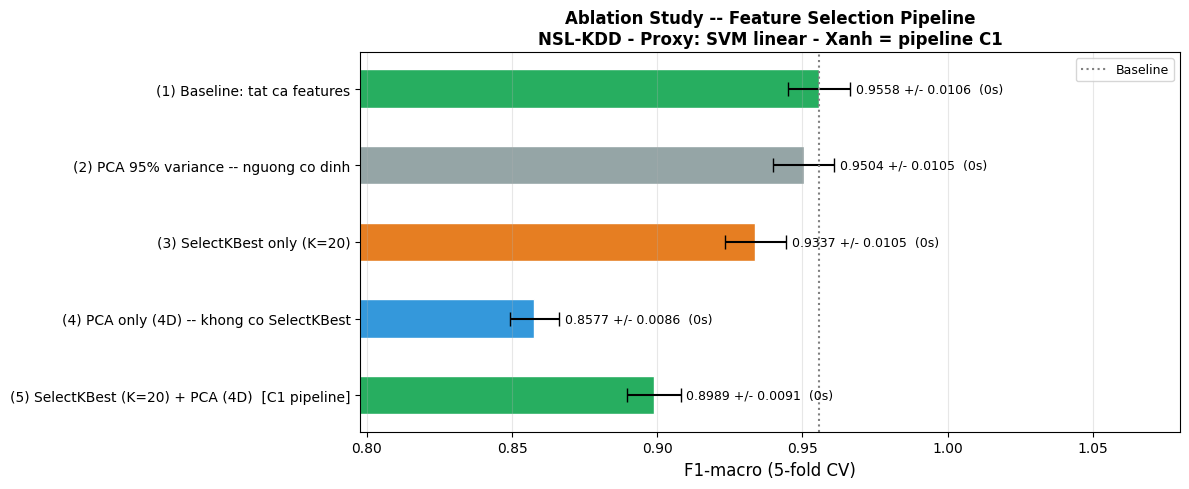

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
palette = ['#95a5a6', '#e67e22', '#3498db', '#27ae60']
y_pos   = np.arange(len(abl_df))
ax.barh(y_pos, abl_df['F1-macro'][::-1], xerr=abl_df['Std'][::-1],
        color=palette[::-1], edgecolor='white', capsize=5, height=0.5)
for i, (f1, std, t) in enumerate(zip(
        abl_df['F1-macro'][::-1], abl_df['Std'][::-1], abl_df['Time_s'][::-1])):
    ax.text(f1 + std + 0.002, i, f'{f1:.4f} +/- {std:.4f}  ({t:.0f}s)', va='center', fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(abl_df['Config'][::-1], fontsize=10)
ax.axvline(x=abl_df['F1-macro'].iloc[0], color='gray', linestyle=':', linewidth=1.5, label='Baseline')
ax.set_xlabel('F1-macro (5-fold CV)', fontsize=12)
ax.set_title('Ablation Study -- Feature Selection Pipeline\n'
             'NSL-KDD - Proxy: SVM linear - Xanh = pipeline C1', fontsize=12, fontweight='bold')
ax.set_xlim(abl_df['F1-macro'].min() - 0.06, 1.08)
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Luu tat ca output

In [29]:
# -- 1. Dataset sau SelectKBest -- giu DAY DU 4 cot nhan --
train_sel_df = pd.DataFrame(X_train_sel, columns=selected_feats)
train_sel_df = pd.concat([train_sel_df, train_meta.reset_index(drop=True)], axis=1)

test_sel_df  = pd.DataFrame(X_test_sel, columns=selected_feats)
test_sel_df  = pd.concat([test_sel_df, test_meta.reset_index(drop=True)], axis=1)

train_sel_df.to_csv(f'{OUTPUT_DIR}/NSL_KDD_Train_Selected.csv', index=False)
test_sel_df.to_csv(f'{OUTPUT_DIR}/NSL_KDD_Test_Selected.csv',  index=False)

# -- 2. Transformer -- .joblib (sklearn-recommended, handle numpy arrays tot hon pickle) --
joblib.dump(selector, f'{MODELS_DIR}/feature_selector_k{K_FINAL}.joblib')

# -- 3. Scores & metadata --
score_df.to_csv(f'{OUTPUT_DIR}/f_scores_all_features.csv',    index=False)
sel_df.to_csv(f'{OUTPUT_DIR}/f_scores_selected_features.csv', index=False)
cv_df.to_csv(f'{OUTPUT_DIR}/selectkbest_cv_results.csv',      index=False)
abl_df.to_csv(f'{OUTPUT_DIR}/ablation_study_results.csv',     index=False)
pd.Series(selected_feats).to_csv(f'{OUTPUT_DIR}/selected_feature_names.csv',
                                  index=False, header=['feature'])

print('=== DA LUU ===')
for fname, info in [
    ('NSL_KDD_Train_Selected.csv',           train_sel_df.shape),
    ('NSL_KDD_Test_Selected.csv',            test_sel_df.shape),
    (f'models/feature_selector_k{K_FINAL}.joblib', 'SelectKBest object'),
    ('f_scores_all_features.csv',            f'{len(score_df)} features'),
    ('f_scores_selected_features.csv',       f'{K_FINAL} features'),
    ('selectkbest_cv_results.csv',           f'{len(cv_df)} K values'),
    ('ablation_study_results.csv',           f'{len(abl_df)} configs'),
    ('selected_feature_names.csv',           f'{K_FINAL} names'),
]:
    print(f'  {fname:<50} {str(info)}')

print(f'\n-> Buoc tiep theo: pca_pareto.ipynb')
print(f'   Input : NSL_KDD_Train_Selected.csv ({K_FINAL} features + 4 cot nhan)')
print(f'   Target: {K_FINAL} features -> PCA multi-objective -> QSVM')

=== DA LUU ===
  NSL_KDD_Train_Selected.csv                         (125973, 24)
  NSL_KDD_Test_Selected.csv                          (22544, 24)
  models/feature_selector_k20.joblib                 SelectKBest object
  f_scores_all_features.csv                          122 features
  f_scores_selected_features.csv                     20 features
  selectkbest_cv_results.csv                         13 K values
  ablation_study_results.csv                         5 configs
  selected_feature_names.csv                         20 names

-> Buoc tiep theo: pca_pareto.ipynb
   Input : NSL_KDD_Train_Selected.csv (20 features + 4 cot nhan)
   Target: 20 features -> PCA multi-objective -> QSVM


## 10. Paper-ready summary

In [30]:
c1_row   = abl_df[abl_df['Config'].str.startswith('(4)')].iloc[0]
base_row = abl_df.iloc[0]
skb_row  = abl_df[abl_df['Config'].str.startswith('(3)')].iloc[0]

print('=' * 68)
print('  SUMMARY -- SelectKBest Feature Selection (NSL-KDD)')
print('=' * 68)
print(f'  Score function                     : f_classif (ANOVA F-test)')
print(f'  Zero-leakage                       : fit_transform(train) / transform(test)')
print(f'  Features ban dau (sau OHE)         : {X_train.shape[1]}')
print(f'  K toi uu (elbow criterion, 5-CV)   : {K_FINAL}')
print(f'  Reduction                          : {X_train.shape[1]} -> {K_FINAL} '
      f'({(1-K_FINAL/X_train.shape[1])*100:.1f}%)')
print()
print(f'  F1-macro baseline (all features)   : '
      f"{base_row['F1-macro']:.4f} +/- {base_row['Std']:.4f}")
print(f'  F1-macro SelectKBest only (K={K_FINAL:<3}) : '
      f"{skb_row['F1-macro']:.4f} +/- {skb_row['Std']:.4f}")
print(f'  F1-macro C1 pipeline (SKB+PCA {PCA_N}D) : '
      f"{c1_row['F1-macro']:.4f} +/- {c1_row['Std']:.4f}")
print(f'  Delta C1 vs baseline               : '
      f"{c1_row['F1-macro']-base_row['F1-macro']:+.4f}")
print()
print(f'  Features duoc chon ({K_FINAL}):')
for _, row in sel_df.iterrows():
    print(f"    {int(row['final_rank']):2d}. {row['feature']:<42} "
          f"F={row['f_score']:.1f}  MI_bin={row['mi_binary']:.4f}")
print()
print(f'  Transformer da luu: models/feature_selector_k{K_FINAL}.joblib')
print(f'  -> PCA input  : {K_FINAL} features')
print(f'  -> QSVM input : {PCA_N} PCA components ({PCA_N} qubit)')
print('=' * 68)

  SUMMARY -- SelectKBest Feature Selection (NSL-KDD)
  Score function                     : f_classif (ANOVA F-test)
  Zero-leakage                       : fit_transform(train) / transform(test)
  Features ban dau (sau OHE)         : 122
  K toi uu (elbow criterion, 5-CV)   : 20
  Reduction                          : 122 -> 20 (83.6%)

  F1-macro baseline (all features)   : 0.9558 +/- 0.0106
  F1-macro SelectKBest only (K=20 ) : 0.9337 +/- 0.0105
  F1-macro C1 pipeline (SKB+PCA 4D) : 0.8577 +/- 0.0086
  Delta C1 vs baseline               : -0.0980

  Features duoc chon (20):
     1. flag_SF                                    F=168332.1  MI_bin=0.3334
     2. same_srv_rate                              F=163826.6  MI_bin=0.3602
     3. dst_host_srv_count                         F=137591.7  MI_bin=0.3333
     4. dst_host_same_srv_rate                     F=116945.5  MI_bin=0.3073
     5. logged_in                                  F=114585.8  MI_bin=0.2862
     6. dst_host_srv_serror_rate 